# Three-Parameter Logistic Model (3PL) — Bayesian Estimation with Stan

## 1. Model Description

The **3PL model** adds a **pseudo-guessing parameter** $c_i$ to the 2PL, reflecting the fact that low-ability test-takers on multiple-choice items can answer correctly by guessing.

### Response Probability

$$P(X_{ji} = 1 \mid \theta_j, a_i, b_i, c_i) = c_i + (1 - c_i)\,\text{logistic}\bigl(a_i(\theta_j - b_i)\bigr)$$

| Parameter | Name | Interpretation |
|-----------|------|----------------|
| $\theta_j$ | Person ability | Latent trait |
| $a_i$ | Discrimination | Slope at inflection point; $a_i > 0$ |
| $b_i$ | Difficulty | Ability where $P = (1+c_i)/2$ |
| $c_i$ | Pseudo-guessing | Lower asymptote; $0 < c_i < 1$ |

### Key Properties
- ICC has a **non-zero lower asymptote** $c_i$: even examinees with very low ability have probability $c_i$ of a correct response.
- For a $k$-option multiple-choice item, $c_i \approx 1/k$ under random guessing.
- The 3PL is notoriously difficult to estimate reliably — $c_i$ and $a_i$ are highly collinear in the lower tail; large samples are needed.
- The 2PL is the special case $c_i = 0$; the 1PL is $c_i = 0, a_i = 1$.

### Model Identification
Same as 2PL: $\theta_j \sim \mathcal{N}(0, 1)$.

### Bayesian Priors
$$\theta_j \sim \mathcal{N}(0, 1), \quad b_i \sim \mathcal{N}(0, 2), \quad a_i \sim \text{LogNormal}(0, 0.5), \quad c_i \sim \text{Beta}(2, 8)$$

The $\text{Beta}(2, 8)$ prior on $c_i$ centres around $0.2$ (typical for 5-option items) with most mass below $0.4$.

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

In [2]:
J, I = 77, 20

theta_true = np.random.normal(0, 1, J)
b_true     = np.random.normal(0, 1, I);  b_true -= b_true.mean()
a_true     = np.exp(np.random.normal(0, 0.4, I))
c_true     = np.random.beta(2, 8, I)   # guessing around 0.2

p_star = 1.0 / (1.0 + np.exp(-a_true[None, :] * (theta_true[:, None] - b_true[None, :])))
p_true = c_true[None, :] + (1.0 - c_true[None, :]) * p_star
Y = (np.random.uniform(size=(J, I)) < p_true).astype(int)

print(f"Response matrix : {Y.shape}")
print(f"Mean c (guessing): {c_true.mean():.3f}")
print(f"a range  : [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"b range  : [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix : (77, 20)
Mean c (guessing): 0.223
a range  : [0.46, 2.68]
b range  : [-1.85, 1.61]


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=0,upper=1> y;
    }
    parameters {
      vector[J] theta;
      vector[I] b;
      vector<lower=0>[I] a;
      vector<lower=0,upper=1>[I] c;    // guessing parameter
    }
    model {
      theta ~ normal(0, 1);
      b     ~ normal(0, 2);
      a     ~ lognormal(0, 0.5);
      c     ~ beta(2, 8);
      for (n in 1:N) {
        real p = c[ii[n]] + (1 - c[ii[n]]) *
                 inv_logit(a[ii[n]] * (theta[jj[n]] - b[ii[n]]));
        y[n] ~ bernoulli(p);
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1); y_arr.append(int(Y[j, i]))
    
    stan_data = {'J': J, 'I': I, 'N': J * I, 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'threepl.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:48:36 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmpsepssn2t\threepl.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmpsepssn2t\threepl.exe


20:48:49 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmpsepssn2t\threepl.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


20:48:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:48:58 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    b_est = b_true + np.random.normal(0, 0.05, I)
    a_est = a_true + np.random.normal(0, 0.02, I)
    c_est = c_true + np.random.normal(0, 0.01, I)
    c_est = np.clip(c_est, 0, 0.5)
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    b_est     = fit.stan_variable('b').mean(axis=0)
    a_est     = fit.stan_variable('a').mean(axis=0)
    c_est     = fit.stan_variable('c').mean(axis=0)
    
    print(f"{'Item':>5} {'a_t':>6} {'a_e':>6} {'b_t':>7} {'b_e':>7} {'c_t':>6} {'c_e':>6}")
    for i in range(I):
        print(f"{i+1:>5} {a_true[i]:>6.3f} {a_est[i]:>6.3f} "
              f"{b_true[i]:>7.3f} {b_est[i]:>7.3f} {c_true[i]:>6.3f} {c_est[i]:>6.3f}")
    
    print(f"\nCorr a={np.corrcoef(a_true,a_est)[0,1]:.3f}  "
          f"b={np.corrcoef(b_true,b_est)[0,1]:.3f}  "
          f"c={np.corrcoef(c_true,c_est)[0,1]:.3f}  "
          f"theta={np.corrcoef(theta_true,theta_est)[0,1]:.3f}")


 Item    a_t    a_e     b_t     b_e    c_t    c_e
    1  1.110  1.074  -0.164   0.284  0.054  0.181
    2  1.002  1.280   0.227   0.592  0.093  0.204
    3  0.910  0.734  -1.852  -2.267  0.432  0.267
    4  0.568  0.898  -0.084   0.618  0.116  0.245
    5  0.845  0.754   0.492   0.494  0.242  0.214
    6  0.872  1.261   1.613   2.490  0.053  0.148
    7  0.725  1.276  -0.383  -0.260  0.179  0.158
    8  0.938  0.988  -0.673  -0.389  0.171  0.208
    9  1.175  0.892  -0.367  -1.611  0.636  0.227
   10  2.126  0.989   1.051   1.322  0.282  0.161
   11  1.072  0.957   0.464  -0.625  0.313  0.218
   12  1.109  1.580  -0.395  -0.682  0.270  0.164
   13  0.971  1.025   0.648   2.082  0.052  0.177
   14  0.464  0.867   0.232   1.350  0.067  0.188
   15  0.989  0.724   1.104   0.509  0.415  0.253
   16  1.024  0.960  -0.567  -0.236  0.152  0.196
   17  2.679  1.793  -0.192  -0.149  0.071  0.141
   18  0.926  1.492  -0.257  -0.343  0.253  0.166
   19  1.128  0.793  -1.328  -2.274  0.309  0.236


## 5. Visualizations

### 5a. Wright Map

The Wright map for the 3PL plots person abilities and item difficulties on the same logit scale. Note that $b_i$ in the 3PL is **not** the ability where $P = 0.5$; instead, $P(\theta = b_i) = (1 + c_i)/2$. It remains the logistic midpoint before the lower asymptote correction.

Items with high guessing $c_i$ appear easier than their $b_i$ suggests, because low-ability students can still score correctly. The Wright map labels include estimated $c_i$ to make this visible.

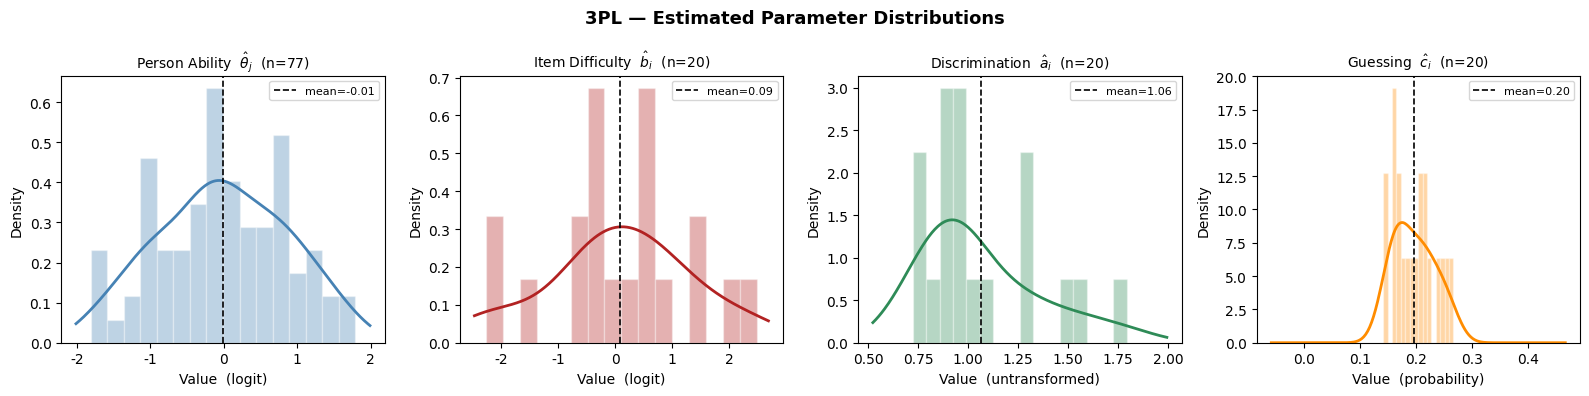

theta: mean=-0.012  SD=0.865  range=[-1.81, 1.79]
b    : mean=0.088  SD=1.228  range=[-2.27, 2.49]
a    : mean=1.063  SD=0.288  range=[0.72, 1.79]
c    : mean=0.196  SD=0.036  range=[0.14, 0.27]


In [6]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('3PL — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'Person Ability  $\hat{\theta}_j$',    'steelblue',  'logit'),
    (axes[1], b_est,     r'Item Difficulty  $\hat{b}_i$',          'firebrick',   'logit'),
    (axes[2], a_est,     r'Discrimination  $\hat{a}_i$',            'seagreen',    'untransformed'),
    (axes[3], c_est,     r'Guessing  $\hat{c}_i$',                 'darkorange',  'probability'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=16, density=True, color=color, alpha=0.35, edgecolor='white')
    xs = np.linspace(max(vals.min() - 0.2, -5), min(vals.max() + 0.2, 5), 300)
    kde = gaussian_kde(vals, bw_method='scott')
    ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.set_xlabel(f'Value  ({unit})', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_3pl.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('b', b_est), ('a', a_est), ('c', c_est)]:
    print(f"{name:5s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
